# **Web Scraping and Analysing Reddit Posts**

## Step 1: Crawling a Real-world Dataset

##### This analysis is based on data scraped from Reddit, a social media platform and forum-style website where members post contents and these content and posts are promoted through voting. <br><br> Reddit is organized into subreddits, which are communities built around shared interest. <br><br> This data was collected from **r/AmItheAsshole**, a subreddit where people share personal conflicts and ask whether they were in the right or wrong. <br><br> This subreddit was chosen because the posts are rich in content and engagement, making it suitable for analyzing post length, scores, comments, and members' interactions.

In [ ]:
# Import libraries
import time
import httpx
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
pd.set_option('display.max_columns', None)
from wordcloud import WordCloud

In [ ]:

# Base url is for the website i.e Reddit and endpoint is the subreddit.
# The posts to be scraped are the top posts in this year.
base_url = 'https://www.reddit.com'
endpoint = 'r/AmItheAsshole'
listing = 'top'


# Gets data in json format
url = f'{base_url}/{endpoint}/{listing}.json'


In [ ]:
# Fetch 5 pages of posts (100 per page)
# Use headers and pauses to avoid getting blocked by Reddit
# Store all collected post in 'dataset' list


# Empty list for the data
dataset = []
after_post_id = None

# Use headers to prevent getting blocked 
headers = {'User-agent': 'spda'}

# Loop to fetch 500 posts
for i in range(5):

    params = {
    'limit': 100,
    't': 'year',
    'after': after_post_id
    }


    response = httpx.get(url, 
                         params=params,
                         headers = headers,
                         timeout=10)
    print(f'fetching {response.url}....')
    
    # This will stop the process if Reddit blocks it
    if response.status_code != 200:
        raise Exception(f'Failed to fetch data: {response.status_code}')
    
    json_data = response.json()

    dataset.extend([rec['data'] for rec in json_data['data']['children']])

    after_post_id = json_data['data']['after']

    if after_post_id is None:
        break
    
    # Pause between requests to avoid getting blocked
    time.sleep(1)
    
print(f'Total posts fetched: {len(dataset)}')   
    


fetching https://www.reddit.com/r/AmItheAsshole/top.json?limit=100&t=year&after=....
fetching https://www.reddit.com/r/AmItheAsshole/top.json?limit=100&t=year&after=t3_1ilzyn6....
fetching https://www.reddit.com/r/AmItheAsshole/top.json?limit=100&t=year&after=t3_1ld6790....
Total posts fetched: 247


##### The loop was set to fetch 500 posts but only 247 was fetched. This is because Reddit's pagination ended before it got to 5 pages.

In [ ]:

# Save collected posts to a json file
with open('AmItheAsshole_reddit_data.json', 'w', encoding='utf-8') as f:
    json.dump(dataset,f, indent=2, ensure_ascii=False)


In [7]:
# Convert the data to dataframe and then to a CSV file.
reddit_df = pd.DataFrame(dataset)
reddit_df.to_csv('scraped_reddit_data.csv', index=False)

In [ ]:
# Import the CSV file
reddit_df = pd.read_csv('scraped_reddit_data.csv')

In [ ]:
# View the first 5 rows to check the data
reddit_df.head()

,approved_at_utc,subreddit,selftext,user_reports,saved,mod_reason_title,gilded,clicked,title,link_flair_richtext,...,subreddit_subscribers,created_utc,num_crossposts,media,is_video,author_fullname,author_premium,author_flair_richtext,author_flair_type,author_patreon_flair
0,NaN,AmItheAsshole,"I 42M, have two kids living with me, my daught...",[],False,NaN,0,False,AITA for enforcing basic boundaries on my daug...,[],...,24077581,1.749920e+09,5,NaN,False,NaN,NaN,NaN,NaN,NaN
1,NaN,AmItheAsshole,"The thing is, his family is constantly judging...",[],False,NaN,0,False,AITA: My husband will invite his family and fr...,[],...,24077581,1.748746e+09,0,NaN,False,NaN,NaN,NaN,NaN,NaN
2,NaN,AmItheAsshole,AITA \n\nI'm currently on a Solo trip in Tener...,[],False,NaN,0,False,AITA for ordering alcohol?,[],...,24077581,1.749736e+09,5,NaN,False,t2_xodz1zpd7,False,[],text,False
3,NaN,AmItheAsshole,My (50) son (17) recently got into a car accid...,[],False,NaN,0,False,AITA for not stopping my teenage sons gf from ...,[],...,24077581,1.748718e+09,4,NaN,False,t2_1qj76u4jpa,False,[],text,False
4,NaN,AmItheAsshole,"To preface this, I do commissioned artwork, an...",[],False,NaN,0,False,AITA for not disclosing that I am not Christian?,[],...,24077581,1.747979e+09,1,NaN,False,t2_3yvsx67j,False,[],text,False


## Step 2: Data Cleaning and Preparation

In [6]:
# Make a copy of the data
df = reddit_df.copy()

In [ ]:
# Get a summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Columns: 103 entries, approved_at_utc to author_patreon_flair
dtypes: bool(28), float64(26), int64(10), object(39)
memory usage: 151.6+ KB


In [ ]:
# View all the columns 
df.columns.tolist()

['approved_at_utc',
 'subreddit',
 'selftext',
 'user_reports',
 'saved',
 'mod_reason_title',
 'gilded',
 'clicked',
 'title',
 'link_flair_richtext',
 'subreddit_name_prefixed',
 'hidden',
 'pwls',
 'link_flair_css_class',
 'downs',
 'top_awarded_type',
 'hide_score',
 'name',
 'quarantine',
 'link_flair_text_color',
 'upvote_ratio',
 'author_flair_background_color',
 'subreddit_type',
 'ups',
 'total_awards_received',
 'media_embed',
 'author_flair_template_id',
 'is_original_content',
 'secure_media',
 'is_reddit_media_domain',
 'is_meta',
 'category',
 'secure_media_embed',
 'link_flair_text',
 'can_mod_post',
 'score',
 'approved_by',
 'is_created_from_ads_ui',
 'thumbnail',
 'edited',
 'author_flair_css_class',
 'gildings',
 'content_categories',
 'is_self',
 'mod_note',
 'created',
 'link_flair_type',
 'wls',
 'removed_by_category',
 'banned_by',
 'domain',
 'allow_live_comments',
 'selftext_html',
 'likes',
 'suggested_sort',
 'banned_at_utc',
 'view_count',
 'archived',
 'no_

##### Select variables that will be used for analysis, including the meanings of each variables. <br> <br>**selftext** - full body of post <br> **title** - title of the post <br> **upvote_ratio** - Fraction of upvotes vs total votes <br>**link_flair_text** - judgement on the post <br> **score** - upvote minus downvote score <br> **created_utc**- timestamp of when the post was made <br> **num_comments** -number of comments under a post <br> **url** - link to the post <br> **num_crossposts** - no of posts shared with another community

In [9]:
# Select columns for analysis

df = df[['title', 'selftext', 'upvote_ratio','ups', 'link_flair_text',
   'score', 'created_utc', 'num_comments', 'num_crossposts', 'url']]

In [10]:
df.head()

,title,selftext,upvote_ratio,ups,link_flair_text,score,created_utc,num_comments,num_crossposts,url
0,AITA for enforcing basic boundaries on my daug...,"I 42M, have two kids living with me, my daught...",0.94,36407,Not the A-hole POO Mode,36407,1.749920e+09,2561,5,https://www.reddit.com/r/AmItheAsshole/comment...
1,AITA: My husband will invite his family and fr...,"The thing is, his family is constantly judging...",0.94,35736,Not the A-hole POO Mode,35736,1.748746e+09,3009,0,https://www.reddit.com/r/AmItheAsshole/comment...
2,AITA for ordering alcohol?,AITA \n\nI'm currently on a Solo trip in Tener...,0.92,32896,Not the A-hole POO Mode,32896,1.749736e+09,2040,5,https://www.reddit.com/r/AmItheAsshole/comment...
3,AITA for not stopping my teenage sons gf from ...,My (50) son (17) recently got into a car accid...,0.93,28534,Not the A-hole,28534,1.748718e+09,5564,4,https://www.reddit.com/r/AmItheAsshole/comment...
4,AITA for not disclosing that I am not Christian?,"To preface this, I do commissioned artwork, an...",0.93,27525,Not the A-hole,27525,1.747979e+09,3274,1,https://www.reddit.com/r/AmItheAsshole/comment...


In [ ]:
# Get data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            247 non-null    object 
 1   selftext         247 non-null    object 
 2   upvote_ratio     247 non-null    float64
 3   ups              247 non-null    int64  
 4   link_flair_text  245 non-null    object 
 5   score            247 non-null    int64  
 6   created_utc      247 non-null    float64
 7   num_comments     247 non-null    int64  
 8   num_crossposts   247 non-null    int64  
 9   url              247 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 19.4+ KB


##### Checking and removal of duplicates: <br> This is so that we are sure there are no 2 rows that have the same observations. It is possible that a post was posted more than once.

In [ ]:
# Check duplicates
duplicated = df.duplicated()
df[duplicated]

,title,selftext,upvote_ratio,ups,link_flair_text,score,created_utc,num_comments,num_crossposts,url


##### There are no duplicate posts.

##### The total number of posts scraped are 247. Check to see if any rows have missing data.

In [13]:
# Check missing data 

df.isnull().sum()

title              0
selftext           0
upvote_ratio       0
ups                0
link_flair_text    2
score              0
created_utc        0
num_comments       0
num_crossposts     0
url                0
dtype: int64

##### 'link_flair_text' has 2 missing values. First, we'll look at the content of this column. 

In [ ]:
df['link_flair_text'].unique()

array(['Not the A-hole POO Mode', 'Not the A-hole', 'Asshole POO Mode',
       'Everyone Sucks', 'No A-holes here', 'META',
       'POO Mode Activated 💩', 'Asshole', 'Everyone Sucks POO Mode', nan,
       'UPDATE', 'Not enough info', 'No A-holes here POO Mode'],
      dtype=object)

##### These flairs will help us understand how judgements are distributed in this subreddit. <br> So what do we do to the missing data? <br> Let's view where these 2 are missing. 

In [15]:
# View rows where 'link_flair_test' is missing
df[df['link_flair_text'].isna()]

,title,selftext,upvote_ratio,ups,link_flair_text,score,created_utc,num_comments,num_crossposts,url
93,AITA? My wife is super pissed off,"I have been married For 5 years with My wife, ...",0.96,13218,NaN,13218,1.735840e+09,4013,2,https://www.reddit.com/r/AmItheAsshole/comment...
120,AITA for not bringing my daughter’s friend hom...,My daughter and I live about an hour outside N...,0.95,11998,NaN,11998,1.759168e+09,1006,3,https://www.reddit.com/r/AmItheAsshole/comment...


##### Since they are just 2 rows, and there is no way to infer the value, these 2 rows will be dropped.

In [16]:
# Drop rows where 'link_flair_text' is missing

df = df.dropna(subset=['link_flair_text'])

In [17]:
# Check they have been removed

df[df['link_flair_text'].isna()]

,title,selftext,upvote_ratio,ups,link_flair_text,score,created_utc,num_comments,num_crossposts,url


In [18]:
df.head()

,title,selftext,upvote_ratio,ups,link_flair_text,score,created_utc,num_comments,num_crossposts,url
0,AITA for enforcing basic boundaries on my daug...,"I 42M, have two kids living with me, my daught...",0.94,36407,Not the A-hole POO Mode,36407,1.749920e+09,2561,5,https://www.reddit.com/r/AmItheAsshole/comment...
1,AITA: My husband will invite his family and fr...,"The thing is, his family is constantly judging...",0.94,35736,Not the A-hole POO Mode,35736,1.748746e+09,3009,0,https://www.reddit.com/r/AmItheAsshole/comment...
2,AITA for ordering alcohol?,AITA \n\nI'm currently on a Solo trip in Tener...,0.92,32896,Not the A-hole POO Mode,32896,1.749736e+09,2040,5,https://www.reddit.com/r/AmItheAsshole/comment...
3,AITA for not stopping my teenage sons gf from ...,My (50) son (17) recently got into a car accid...,0.93,28534,Not the A-hole,28534,1.748718e+09,5564,4,https://www.reddit.com/r/AmItheAsshole/comment...
4,AITA for not disclosing that I am not Christian?,"To preface this, I do commissioned artwork, an...",0.93,27525,Not the A-hole,27525,1.747979e+09,3274,1,https://www.reddit.com/r/AmItheAsshole/comment...


##### Let's look at 'created_utc' - timestamp when the post was made.

In [19]:
df['created_utc']

0      1.749920e+09
1      1.748746e+09
2      1.749736e+09
3      1.748718e+09
4      1.747979e+09
           ...     
242    1.757685e+09
243    1.736231e+09
244    1.743124e+09
245    1.734683e+09
246    1.748532e+09
Name: created_utc, Length: 245, dtype: float64

##### The data type is float and it is in a non-readable format(Unix time) so it needs to be converted to a readable date.

In [20]:
# Convert created_utc to datetime object

df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')

In [ ]:
# Confirm the datetime format
df['created_utc']

0     2025-06-14 16:47:41
1     2025-06-01 02:42:13
2     2025-06-12 13:41:08
3     2025-05-31 19:02:39
4     2025-05-23 05:40:24
              ...        
242   2025-09-12 13:57:35
243   2025-01-07 06:31:30
244   2025-03-28 00:58:23
245   2024-12-20 08:29:18
246   2025-05-29 15:12:10
Name: created_utc, Length: 245, dtype: datetime64[ns]

##### **url** column is unnecessary so it will be dropped.

In [22]:
# Drop url
df = df.drop(columns='url')

In [23]:
df.head()

,title,selftext,upvote_ratio,ups,link_flair_text,score,created_utc,num_comments,num_crossposts
0,AITA for enforcing basic boundaries on my daug...,"I 42M, have two kids living with me, my daught...",0.94,36407,Not the A-hole POO Mode,36407,2025-06-14 16:47:41,2561,5
1,AITA: My husband will invite his family and fr...,"The thing is, his family is constantly judging...",0.94,35736,Not the A-hole POO Mode,35736,2025-06-01 02:42:13,3009,0
2,AITA for ordering alcohol?,AITA \n\nI'm currently on a Solo trip in Tener...,0.92,32896,Not the A-hole POO Mode,32896,2025-06-12 13:41:08,2040,5
3,AITA for not stopping my teenage sons gf from ...,My (50) son (17) recently got into a car accid...,0.93,28534,Not the A-hole,28534,2025-05-31 19:02:39,5564,4
4,AITA for not disclosing that I am not Christian?,"To preface this, I do commissioned artwork, an...",0.93,27525,Not the A-hole,27525,2025-05-23 05:40:24,3274,1


##### Cleaning of text in the posts and titles: <br> Some of the text contain characters such as punctuations, or even extra spaces. <br> In the titles of the posts, users usually start with 'AITA' (Am I the asshole) or 'WIBTA'(Would I be the asshole); these phrases were removed so they don't dominate in the word cloud.

In [ ]:
# Check the title for occurences of AITA & WIBTA
df['title'].str.contains('AITA|WIBTA', case=False).sum()

np.int64(244)

In [ ]:
# Check the post for AITA & WIBTA
df['selftext'].str.contains('AITA|WIBTA', case=False).sum()

np.int64(139)

In [ ]:
# Function for cleaning the text

def text_cleaned(text):
    """
    This function cleans the body of
    all the posts. It will remove the 
    white spaces, punctuation, aita, & wibta.
    """
    # Convert all texts to lower case
    text = text.lower()
    
    # Remove any text that has aita
    text = re.sub(r'\baita\b|\bwibta\b|\bam i the asshole\b', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

In [27]:
# Apply the function
df['cleaned_text'] = df['selftext'].apply(text_cleaned)

In [ ]:
# Function for cleaning the title

def title_cleaned(title):
    """
    This function cleans the titles of
    all the posts. It will remove the 
    white spaces, punctuation and noise.
    """

    title = title.lower()

    # Remove extra spaces
    title = re.sub(r'\s+', ' ', title)

    # Remove punctuation
    title = re.sub(r'[^\w\s]', '', title)
    
    # Remove AITA, WIBTA
    title = re.sub(r'^(aita|wibta)\s+', '', title)
    return title.strip()

In [30]:
# Apply the function
df['cleaned_title'] = df['title'].apply(title_cleaned)

In [32]:
# Re-arrange the columns 

df = df [[
    'title', 'cleaned_title',
    'selftext', 'cleaned_text',
    'upvote_ratio','ups',
    'link_flair_text','score',
    'created_utc','num_comments',
    'num_crossposts'
]]

In [33]:
df.head()

,title,cleaned_title,selftext,cleaned_text,upvote_ratio,ups,link_flair_text,score,created_utc,num_comments,num_crossposts
0,AITA for enforcing basic boundaries on my daug...,for enforcing basic boundaries on my daughters...,"I 42M, have two kids living with me, my daught...",i 42m have two kids living with me my daughter...,0.94,36407,Not the A-hole POO Mode,36407,2025-06-14 16:47:41,2561,5
1,AITA: My husband will invite his family and fr...,my husband will invite his family and friends ...,"The thing is, his family is constantly judging...",the thing is his family is constantly judging ...,0.94,35736,Not the A-hole POO Mode,35736,2025-06-01 02:42:13,3009,0
2,AITA for ordering alcohol?,for ordering alcohol,AITA \n\nI'm currently on a Solo trip in Tener...,im currently on a solo trip in tenerife all in...,0.92,32896,Not the A-hole POO Mode,32896,2025-06-12 13:41:08,2040,5
3,AITA for not stopping my teenage sons gf from ...,for not stopping my teenage sons gf from kissi...,My (50) son (17) recently got into a car accid...,my 50 son 17 recently got into a car accident ...,0.93,28534,Not the A-hole,28534,2025-05-31 19:02:39,5564,4
4,AITA for not disclosing that I am not Christian?,for not disclosing that i am not christian,"To preface this, I do commissioned artwork, an...",to preface this i do commissioned artwork and ...,0.93,27525,Not the A-hole,27525,2025-05-23 05:40:24,3274,1


##### Check the cleaned title and text again

In [34]:
# Check the title for AITA & WIBTA
df['cleaned_text'].str.contains('AITA|WIBTA', case=False).sum()

np.int64(8)

In [35]:
# Check the title for AITA & WIBTA
df['cleaned_title'].str.contains('AITA|WIBTA', case=False).sum()

np.int64(12)

##### The numbers have reduced drastically, showing that a lot of those phrases were removed. We will leave the rest as they are really small. Further investigation will be done in future.

In [36]:
# Reset index
df = df.reset_index(drop=True)

##### Standardize Flairs.                                         
The raw flairs from r/AmIanAsshole were standardized based on the subreddit definitions. 
 
 - **NTA/YWNBTA** = You are/would be not the asshole (but the other party is) 
 - **YTA/YWBTA** = You are/would be the asshole (and the other party is not)
 - **ESH** = Everyone sucks here (you and the other party are both the asshole) 
 - **NAH** = No assholes here (no one’s an asshole) 
 - **INFO** = More information needed.
 - **POO** = Prevented outbursts online (for posts that are generating high volume of rule-violating comments)

In [37]:
df['link_flair_text'].unique()

array(['Not the A-hole POO Mode', 'Not the A-hole', 'Asshole POO Mode',
       'Everyone Sucks', 'No A-holes here', 'META',
       'POO Mode Activated 💩', 'Asshole', 'Everyone Sucks POO Mode',
       'UPDATE', 'Not enough info', 'No A-holes here POO Mode'],
      dtype=object)

The flairs in the dataset will be matched to these and added to a new column.

In [38]:
# Map the flairs to the clean ones from reddit
map_flair = {
    'Not the A-hole POO Mode': 'NTA', 
    'Not the A-hole' : 'NTA', 
    'Asshole POO Mode':'YTA',
    'Asshole' : 'YTA',
    'Everyone Sucks' : 'ESH',
    'Everyone Sucks POO Mode': 'ESH',
    'No A-holes here': 'NAH',
    'No A-holes here POO Mode' : 'NAH',
    'Not enough info' : 'INFO', 
    'UPDATE' : 'UPDATE',
    'META': 'META',
    'POO Mode Activated 💩': 'POO'
    }

# Apply mapping
df['cleaned_flair'] = df['link_flair_text'].map(map_flair)          

In [39]:
# Check
df['cleaned_flair'].unique()

array(['NTA', 'YTA', 'ESH', 'NAH', 'META', 'POO', 'UPDATE', 'INFO'],
      dtype=object)

Save clean dataset as a CSV

In [45]:
df.to_csv('aita_subreddit_cleaned_data.csv', index=False, encoding='utf-8-sig')

## Step 3: Exploratory Analysis

The data will now be explored

In [40]:
df.describe()

,upvote_ratio,ups,score,created_utc,num_comments,num_crossposts
count,245.000000,245.000000,245.000000,245,245.000000,245.000000
mean,0.944000,13370.379592,13370.379592,2025-05-10 14:20:24.946938624,1765.604082,2.563265
min,0.700000,8800.000000,8800.000000,2024-12-01 21:50:32,35.000000,0.000000
25%,0.930000,10071.000000,10071.000000,2025-02-15 15:44:39,835.000000,1.000000
50%,0.950000,11891.000000,11891.000000,2025-05-13 22:24:21,1368.000000,2.000000
75%,0.970000,15056.000000,15056.000000,2025-07-13 08:18:30,2266.000000,4.000000
max,0.990000,36407.000000,36407.000000,2025-11-25 18:46:27,11884.000000,17.000000
std,0.041404,4717.848007,4717.848007,NaN,1572.239533,2.908629


In [ ]:
# score and ups have the same statistics. 
# Check if the values are all the same across the dataset.
(df['score'] == df['ups']).all()


np.True_

**ups** will be dropped. **score** will be used for the analysis.

In [ ]:
# Drop ups column
df = df.drop(columns='ups')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   title            245 non-null    object        
 1   cleaned_title    245 non-null    object        
 2   selftext         245 non-null    object        
 3   cleaned_text     245 non-null    object        
 4   upvote_ratio     245 non-null    float64       
 5   link_flair_text  245 non-null    object        
 6   score            245 non-null    int64         
 7   created_utc      245 non-null    datetime64[ns]
 8   num_comments     245 non-null    int64         
 9   num_crossposts   245 non-null    int64         
 10  cleaned_flair    245 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 21.2+ KB


In [48]:
df.describe()

,upvote_ratio,score,created_utc,num_comments,num_crossposts
count,245.000000,245.000000,245,245.000000,245.000000
mean,0.944000,13370.379592,2025-05-10 14:20:24.946938624,1765.604082,2.563265
min,0.700000,8800.000000,2024-12-01 21:50:32,35.000000,0.000000
25%,0.930000,10071.000000,2025-02-15 15:44:39,835.000000,1.000000
50%,0.950000,11891.000000,2025-05-13 22:24:21,1368.000000,2.000000
75%,0.970000,15056.000000,2025-07-13 08:18:30,2266.000000,4.000000
max,0.990000,36407.000000,2025-11-25 18:46:27,11884.000000,17.000000
std,0.041404,4717.848007,NaN,1572.239533,2.908629


##### Descriptive summary 
 - In this dataset of top posts, the mean upvote ratio is 0.944, suggesting that these posts were highly voted by community members.
 - On average, posts in this dataset received a score of approximately 13,370 and 1,766 comments.Since the dataset contains only top posts, these values show highly voted posts and their discussions, but do not represent all posts on the subreddit 
- Even among top posts, crossposts are not common, averaging only 2.6 per post. 
- The posts were from 01-December 2024 through 25-November 2025.

Check the number of posts by flair

In [49]:
df['cleaned_flair'].value_counts()

cleaned_flair
NTA       222
YTA         8
ESH         6
NAH         3
META        2
UPDATE      2
POO         1
INFO        1
Name: count, dtype: int64

In [ ]:
# Percentage of posts by flair
df['cleaned_flair'].value_counts(normalize=True)

cleaned_flair
NTA       0.906122
YTA       0.032653
ESH       0.024490
NAH       0.012245
META      0.008163
UPDATE    0.008163
POO       0.004082
INFO      0.004082
Name: proportion, dtype: float64

Over 90% of the posts in this dataset were judged as **Not the asshole(NTA)**. However, the dataset contains only top posts, so it possibly reflects stories that are popular among the community. This raises an interesting question: do humans tend to narrate events or stories in a way that make themselves look good and others appear at fault? 

In [52]:
df.columns.tolist()

['title',
 'cleaned_title',
 'selftext',
 'cleaned_text',
 'upvote_ratio',
 'link_flair_text',
 'score',
 'created_utc',
 'num_comments',
 'num_crossposts',
 'cleaned_flair']

Count the number of words in each post

In [ ]:
# Word count of each posts
df['word_count'] = df['cleaned_text'].str.split().str.len()
df.head()

,title,cleaned_title,selftext,cleaned_text,upvote_ratio,link_flair_text,score,created_utc,num_comments,num_crossposts,cleaned_flair,word_count
0,AITA for enforcing basic boundaries on my daug...,for enforcing basic boundaries on my daughters...,"I 42M, have two kids living with me, my daught...",i 42m have two kids living with me my daughter...,0.94,Not the A-hole POO Mode,36407,2025-06-14 16:47:41,2561,5,NTA,386
1,AITA: My husband will invite his family and fr...,my husband will invite his family and friends ...,"The thing is, his family is constantly judging...",the thing is his family is constantly judging ...,0.94,Not the A-hole POO Mode,35736,2025-06-01 02:42:13,3009,0,NTA,126
2,AITA for ordering alcohol?,for ordering alcohol,AITA \n\nI'm currently on a Solo trip in Tener...,im currently on a solo trip in tenerife all in...,0.92,Not the A-hole POO Mode,32896,2025-06-12 13:41:08,2040,5,NTA,234
3,AITA for not stopping my teenage sons gf from ...,for not stopping my teenage sons gf from kissi...,My (50) son (17) recently got into a car accid...,my 50 son 17 recently got into a car accident ...,0.93,Not the A-hole,28534,2025-05-31 19:02:39,5564,4,NTA,379
4,AITA for not disclosing that I am not Christian?,for not disclosing that i am not christian,"To preface this, I do commissioned artwork, an...",to preface this i do commissioned artwork and ...,0.93,Not the A-hole,27525,2025-05-23 05:40:24,3274,1,NTA,183


Explore the distributions of features

Text(0.5, 0.98, 'Distribution of Numeric Variables')

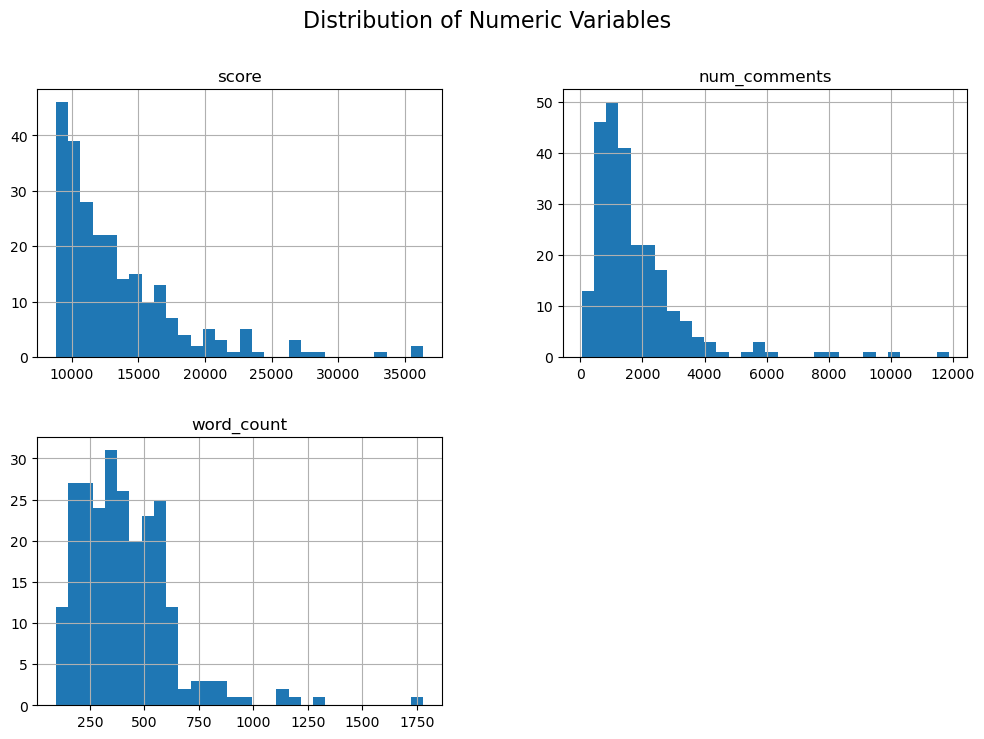

In [ ]:
# Plot histograms of these variables
numeric_variables = ['score', 'num_comments', 'word_count']

df[numeric_variables].hist(bins=30, figsize=(12,8))
plt.suptitle('Distribution of Numeric Variables', fontsize=16)

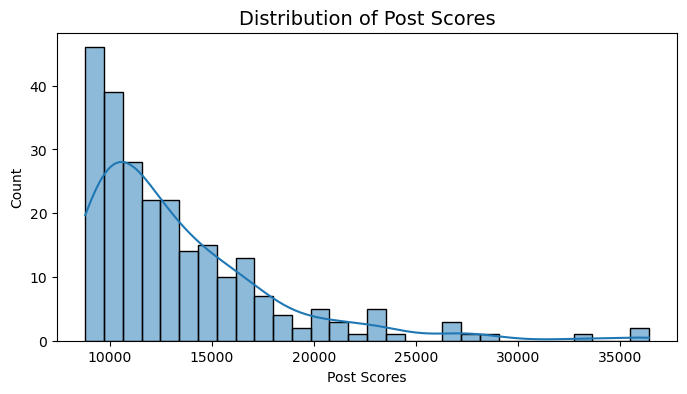

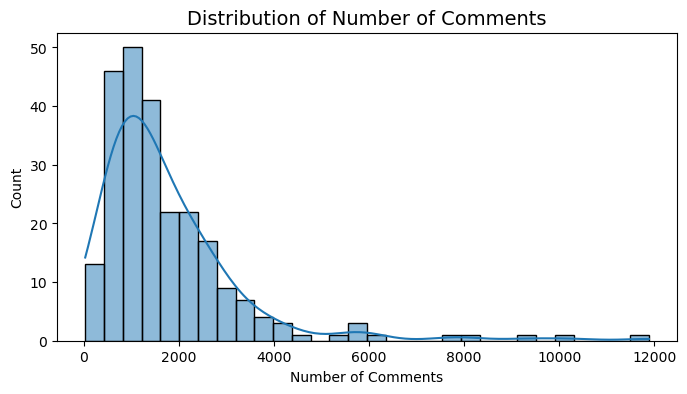

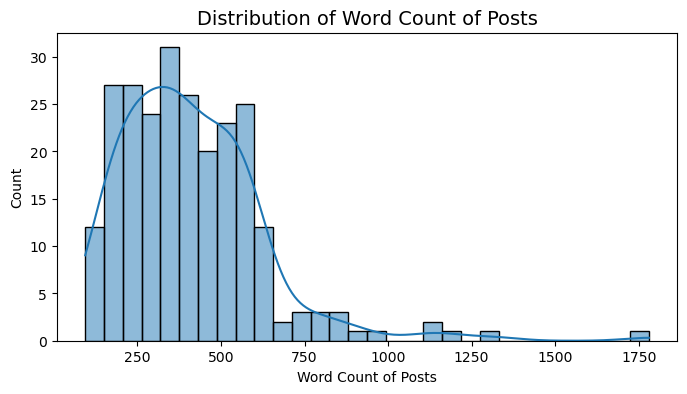

In [60]:
# Rename so that the charts are readable
chart_labels = ['Post Scores', 'Number of Comments', 'Word Count of Posts']

for col, label in zip(numeric_variables, chart_labels):
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {label}', fontsize=14)
    plt.xlabel(label)
    plt.ylabel('Count')
    plt.show()

Histograms Description
- **Distribution of post scores:** The histogram is right-skewed, showing that majority of posts have scores between 10,000 and 15,000, with a few outliers exceeding 30,000.
- **Distribution of comments:** Similarly, the histogram is right-skewed, with most posts receiving between 800 and 2,000 comments, and a few outliers receiving over 6,000 comments.

##### Compare the median of flair categories

In [82]:
df.groupby('cleaned_flair')['score'].agg(['count', 'median'])

,count,median
cleaned_flair,,
ESH,6,12112.0
INFO,1,11001.0
META,2,18047.5
NAH,3,13238.0
NTA,222,11847.0
POO,1,16800.0
UPDATE,2,11924.5
YTA,8,12228.5


The table above compares post scores across flairs using the median rather than the mean. This is because the dataset is highly imbalanced; with the NTA flair having 222 posts while others have less than 10. Moreover, because of these very small samples, the medians are not representative and so we cannot directly compare the scores.

 Plot a bar chart of the distribution of flairs. From the above, we have said that these posts are just the top posts.

C:\Users\uy25979\AppData\Local\Temp\ipykernel_22352\3686435958.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Percentage (%)')

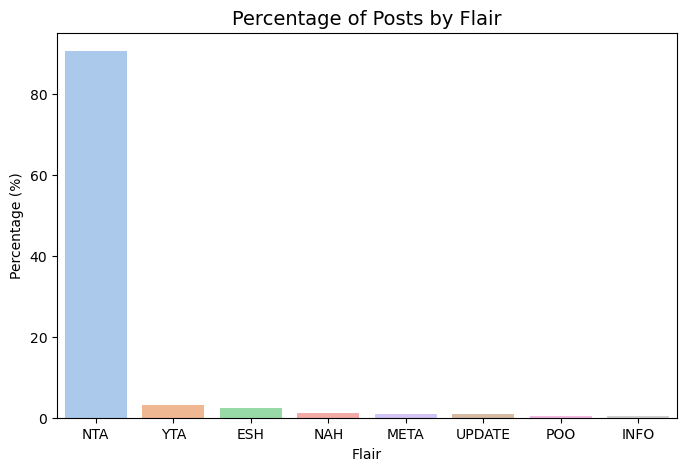

In [61]:
flair_counts = df['cleaned_flair'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
sns.barplot(
    x=flair_counts.index,
    y=flair_counts.values,
    palette='pastel'
)
plt.title('Percentage of Posts by Flair', fontsize=14)
plt.xlabel('Flair')
plt.ylabel('Percentage (%)')

##### Word cloud
- A word cloud is a visual tool for displaying the most frequently used words in a text or set of texts.
- Word cloud will be used on the body of posts that received (NTA- Not the asshole) judgement to see the most frequent words.

In [ ]:
# conda install -c conda-forge wordcloud


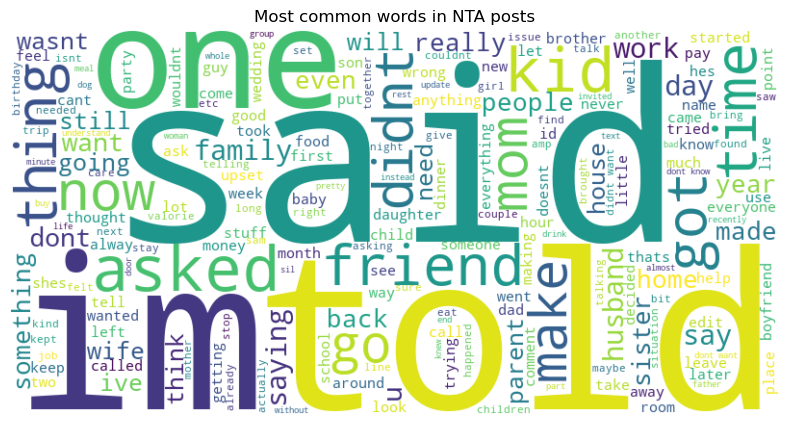

In [ ]:

# Visualize the most frequent words used in NTA posts.
text = ' '.join(df[df['cleaned_flair']=='NTA']['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most common words in NTA posts')
plt.show()


The word cloud highlights words like **'said'**, **'told'**, **I'm**,  **'asked'**,  and so on. This suggests to us that most of these posts were about community members sharing their personal conversations or experiences. The prominence of words like **'family'**, **'kid'**, **'friend'**, **'wife'** etc indicates that most of these narrations revolve around many close relationships. 
Also, **'didn't'** is an obvious word and it confirms the theme of this subreddit which people use for sharing stories od disagreement and ask for judgement.

## Step 4: Ask a Question about Your Data

The following questions will be answered 
- Does the length of an 'AMItheAsshole' post affect how much engagement (score and number of comments) it receives?<br> <br>
**Sub-questions**
1. Is there a linear relationship between the length of post and its score? 
2. Does the word count have a relationship with the number of comments a post receives? 
3. Are longer posts more common in certain flairs (judgements)?

1. Is there a linear relationship between the length of post and its score? <br> <br> Here, we want to assess if the score a post gets is related to how length the post is. <br> We will check the ; 
- correlation 
- plot a scatterplot

##### 1a. Correlation

In [83]:
# Check the correlation between word count and score
df[['word_count', 'score']].corr('spearman')

,word_count,score
word_count,1.000000,0.024283
score,0.024283,1.000000


The correlation is -0.04, this value tells us  that there s little to no relationship between word count and score. In other words, longer posts do not tend to receive higher or lower scores.

1b. Plot a scatterplot.

Text(0.5, 1.0, 'Relationship Between Length of Post and Scores')

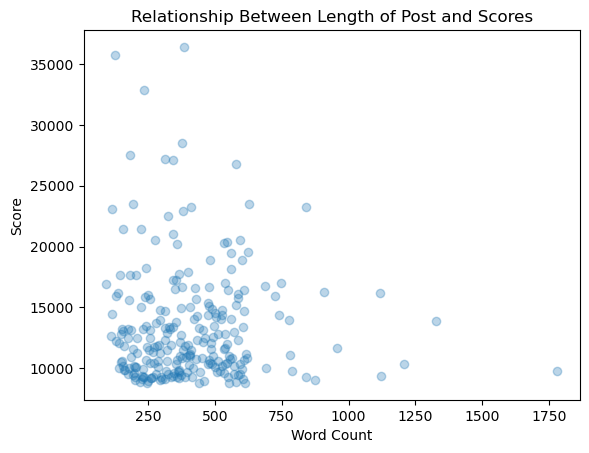

In [84]:
plt.scatter(df['word_count'], df['score'], alpha=0.3)
plt.xlabel('Word Count')
plt.ylabel('Score')
plt.title('Relationship Between Length of Post and Scores')

Although, the points are clustered around the lower values, the scatterplot confirms that the two variables have almost no relationship with each other. There are a few outliers with over 1000 words.

2. Does the word count have a relationship with the number of comments a post receives?

Here we want to see if word count is related to number of comments. Some posts could be long and may lead to many comments so let us explore that.

2a. Correlation

In [85]:
df[['word_count', 'num_comments']].corr('spearman')

,word_count,num_comments
word_count,1.000000,0.060295
num_comments,0.060295,1.000000


2b. Scatterplot

Text(0.5, 1.0, 'Word count vs Number of Comments')

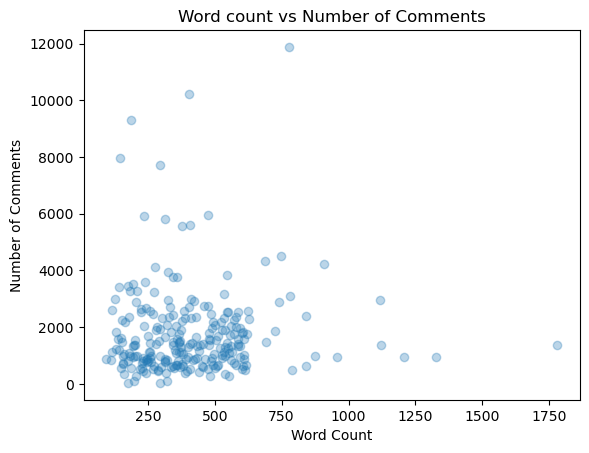

In [86]:
plt.scatter(df['word_count'], df['num_comments'], alpha=0.3)
plt.xlabel('Word Count')
plt.ylabel('Number of Comments')
plt.title('Word count vs Number of Comments')

The scatterplot also tells us that there is also little to no meaningful relationship between number of comments and word counts too. There are a few outlier posts that received over 8,000 comments.

3. Are longer posts more common in certain flairs (judgements)?

In [ ]:
# Check the average word count by flairs
df.groupby('cleaned_flair')['word_count'].mean().sort_values(ascending=False)

cleaned_flair
POO       688.000000
UPDATE    545.500000
YTA       446.375000
ESH       415.166667
NTA       411.472973
INFO      409.000000
META      320.500000
NAH       144.000000
Name: word_count, dtype: float64

Some flairs appear to have longer posts but because the data is highly imbalced (NTA with 222 posts), this finding has a limitation.

## Summary and Conclusion

From this analysis of top r/AmItheAsshole posts, some patterns were noticed. Over 90% of posts received the judgement **Not the Asshole**, suggesting that posts where the narrative is perceived positively are the most popular. 
The word cloud visualization reflected the theme of this subreddit with words showing narrations and interpersonal relationships as the most frequent.
The average score (approximately 13,370) and number of comments (around 1776) further indicated that the scraped posts attracted high community engagement. Although, this was expected because the dataset contained only top posts. 
The data covers a time window between December 2024 and November 2025, and crossposts were rare. 

## Future work
- More in-depth text cleaning could be doneto improve quality of analysis
- Sentiment analysis can be used to examine the emotional tone of posts.This can reveal patterns like anger, frustration, etc.
- Posts could be classified into positive, negative or neutral categories. 